In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
all_results = pd.read_csv("all_models_85_kinases.csv")

best_results = pd.read_csv("best_model_per_kinase.csv")

In [3]:
# Check the dimensions of both datasets

print("All model results shape:", all_results.shape)
print("Best model results shape:",best_results.shape)

All model results shape: (680, 6)
Best model results shape: (85, 6)


In [4]:
# Display the first five rows of both datasets

print("First five rows of all model results:")
display(all_results.head())

print("First five rows of best model results:")
display(best_results.head())

First five rows of all model results:


,Kinase,Model,CV Mean R²,CV Std R²,Test R²,Test MSE
0,O00418,RandomForest,0.229352,0.467790,0.440225,5.379335
1,O00418,XGBoost,-0.203245,0.697583,0.443658,5.346345
2,O00418,PLS,-0.876310,1.576216,0.171546,7.961298
3,O00418,SVR,-2.119992,3.662152,0.147104,8.196175
4,O00418,Lasso,-0.572028,1.013604,0.139454,8.269695


First five rows of best model results:


,Kinase,Model,CV Mean R²,CV Std R²,Test R²,Test MSE
0,O00418,GradientBoosting,0.157575,0.567475,0.493956,4.862995
1,O14578,GradientBoosting,-0.427247,0.312659,0.412093,0.381244
2,O15075,RandomForest,-0.144578,0.457117,0.434111,1.128972
3,O43318,ElasticNet,-0.229869,0.216070,-0.056106,0.547607
4,O43353,PLS,0.364888,0.530895,0.851154,0.247871


In [5]:
# Get kinase information from the Kinepik API

import requests

url = "https://kinepik.org/api/0/kinases/all"

response = requests.get(url)

kinase_info = pd.DataFrame(response.json())

# Create a clean mapping between UniProt ID and gene name
kinase_gene_mapping = pd.DataFrame({
    "Kinase": kinase_info["UniprotID"],
    "GeneName": kinase_info["GeneInfo"].apply(lambda x: x["MappedGene"])
})

# Display the first five rows
display(kinase_gene_mapping.head())

,Kinase,GeneName
0,P06239,LCK
1,P12931,SRC
2,P06241,FYN
3,P00519,ABL1
4,P24941,CDK2


In [6]:
all_results_with_genes = all_results.merge(
    kinase_gene_mapping,
    on="Kinase",
    how="left"
)

print("All results shape:", all_results_with_genes.shape)

print(
    "Missing gene names:",
    all_results_with_genes["GeneName"].isna().sum()
)

All results shape: (680, 7)
Missing gene names: 0


In [7]:
# Add gene names to best results

best_results_with_genes = best_results.merge(
    kinase_gene_mapping,
    on="Kinase",
    how="left"
)

# Arrange GeneName immediately after Kinase

best_results_with_genes = best_results_with_genes[
    [
        "Kinase",
        "GeneName",
        "Model",
        "CV Mean R²",
        "CV Std R²",
        "Test R²",
        "Test MSE"
    ]
]

# Sort best results from highest to lowest Test R²

best_results_sorted = best_results_with_genes.sort_values(
    by="Test R²",
    ascending=False
).reset_index(drop=True)

display(best_results_sorted)

,Kinase,GeneName,Model,CV Mean R²,CV Std R²,Test R²,Test MSE
0,Q9UKE5,TNIK,SVR,0.949891,0.021636,0.975446,0.010548
1,O43353,RIPK2,PLS,0.364888,0.530895,0.851154,0.247871
2,Q96QT4,TRPM7,PLS,0.763893,0.058656,0.699394,0.286459
3,O96013,PAK4,PLS,0.444782,0.404463,0.679369,0.669225
4,Q13043,STK4,GradientBoosting,-0.996092,1.282642,0.667451,0.507225
...,...,...,...,...,...,...,...
80,Q9HBH9,MKNK2,Lasso,-1.197954,1.715732,-0.169180,1.238827
81,O43683,BUB1,Lasso,-0.006128,0.215569,-0.241320,0.749667
82,Q13627,DYRK1A,MLP,-0.569466,0.359906,-0.265633,1.283011
83,Q9H4A3,WNK1,SVR,-1.125072,1.013457,-0.386230,2.590478


In [8]:
# Display the top 10 best-performing results

top_10 = best_results_sorted.head(10)

display(top_10)

,Kinase,GeneName,Model,CV Mean R²,CV Std R²,Test R²,Test MSE
0,Q9UKE5,TNIK,SVR,0.949891,0.021636,0.975446,0.010548
1,O43353,RIPK2,PLS,0.364888,0.530895,0.851154,0.247871
2,Q96QT4,TRPM7,PLS,0.763893,0.058656,0.699394,0.286459
3,O96013,PAK4,PLS,0.444782,0.404463,0.679369,0.669225
4,Q13043,STK4,GradientBoosting,-0.996092,1.282642,0.667451,0.507225
5,P49841,GSK3B,GradientBoosting,-1.442618,2.421778,0.629243,0.428957
6,O60885,BRD4,GradientBoosting,-1.866015,2.844655,0.611658,0.199884
7,Q96SB4,SRPK1,PLS,-0.085490,0.516850,0.603929,0.484244
8,O94806,PRKD3,PLS,0.130682,0.298305,0.595446,0.364353
9,O00418,EEF2K,GradientBoosting,0.157575,0.567475,0.493956,4.862995


In [9]:
# Identify the best and worst performing kinase-model combinations

best_performer = best_results_sorted.iloc[0]
worst_performer = best_results_sorted.iloc[-1]

print("BEST PERFORMING KINASE-MODEL COMBINATION")
print(best_performer)

print("\nWORST PERFORMING KINASE-MODEL COMBINATION")
print(worst_performer)

BEST PERFORMING KINASE-MODEL COMBINATION
Kinase          Q9UKE5
GeneName          TNIK
Model              SVR
CV Mean R²    0.949891
CV Std R²     0.021636
Test R²       0.975446
Test MSE      0.010548
Name: 0, dtype: object

WORST PERFORMING KINASE-MODEL COMBINATION
Kinase          Q9Y3S1
GeneName          WNK2
Model              SVR
CV Mean R²   -0.155072
CV Std R²     0.563966
Test R²      -0.401132
Test MSE      3.445313
Name: 84, dtype: object


In [10]:
# Display the top 10 best and worst-performing kinase-model combinations

top_10_best = best_results_sorted.head(10)

top_10_worst = best_results_sorted.tail(10).sort_values(
    by="Test R²",
    ascending=True
).reset_index(drop=True)

print("TOP 10 BEST-PERFORMING KINASE-MODEL COMBINATIONS")
display(top_10_best)

print("TOP 10 WORST-PERFORMING KINASE-MODEL COMBINATIONS")
display(top_10_worst)

TOP 10 BEST-PERFORMING KINASE-MODEL COMBINATIONS


,Kinase,GeneName,Model,CV Mean R²,CV Std R²,Test R²,Test MSE
0,Q9UKE5,TNIK,SVR,0.949891,0.021636,0.975446,0.010548
1,O43353,RIPK2,PLS,0.364888,0.530895,0.851154,0.247871
2,Q96QT4,TRPM7,PLS,0.763893,0.058656,0.699394,0.286459
3,O96013,PAK4,PLS,0.444782,0.404463,0.679369,0.669225
4,Q13043,STK4,GradientBoosting,-0.996092,1.282642,0.667451,0.507225
5,P49841,GSK3B,GradientBoosting,-1.442618,2.421778,0.629243,0.428957
6,O60885,BRD4,GradientBoosting,-1.866015,2.844655,0.611658,0.199884
7,Q96SB4,SRPK1,PLS,-0.085490,0.516850,0.603929,0.484244
8,O94806,PRKD3,PLS,0.130682,0.298305,0.595446,0.364353
9,O00418,EEF2K,GradientBoosting,0.157575,0.567475,0.493956,4.862995


TOP 10 WORST-PERFORMING KINASE-MODEL COMBINATIONS


,Kinase,GeneName,Model,CV Mean R²,CV Std R²,Test R²,Test MSE
0,Q9Y3S1,WNK2,SVR,-0.155072,0.563966,-0.401132,3.445313
1,Q9H4A3,WNK1,SVR,-1.125072,1.013457,-0.386230,2.590478
2,Q13627,DYRK1A,MLP,-0.569466,0.359906,-0.265633,1.283011
3,O43683,BUB1,Lasso,-0.006128,0.215569,-0.241320,0.749667
4,Q9HBH9,MKNK2,Lasso,-1.197954,1.715732,-0.169180,1.238827
5,Q9HAZ1,CLK4,SVR,-0.221157,0.223875,-0.158527,1.988466
6,Q8IV63,VRK3,MLP,-0.055377,0.207435,-0.145163,1.230756
7,O94921,CDK14,Lasso,-0.192316,0.175882,-0.141420,0.381625
8,P27448,MARK3,GradientBoosting,-1.045481,2.380795,-0.126224,0.763387
9,Q07002,CDK18,RandomForest,-0.419000,0.312252,-0.120284,0.908985


In [11]:
#Saving all the important final dataset 

# save all model results with gene names

all_results_with_genes.to_csv(
    "all_results_with_genes.csv",
    index=False 
)

print("Saved: all_results_with_genes.csv")

Saved: all_results_with_genes.csv


In [12]:
#Save best results for eacch kinase

best_results.to_csv(
    "best_results_with_genes.csv",
    index=False 
)

print("Saved: best_results_with_genes.csv")

Saved: best_results_with_genes.csv


In [13]:
#save sorted best results

best_results_sorted.to_csv(
    "best_results_sorted.csv",
    index=False 
)

print("Saved: best_results_sorted.csv")

Saved: best_results_sorted.csv


In [14]:
#Save top 10 best

top_10_best.to_csv(
    "top_10_best_kinases.csv",
    index=False
)

print("Saved: top_10_best_kinases.csv")

Saved: top_10_best_kinases.csv


In [15]:
# save top 10 worst

top_10_worst.to_csv(
    "top_10_worst_kinases.csv",
    index=False 
)

print("Saved: top_10_worst_kinases.csv")

Saved: top_10_worst_kinases.csv


In [16]:
#Load the predictions CSV

predictions = pd.read_csv("all_predictions.csv")

predictions

,Kinase,GeneName,Model,Actual,Predicted
0,O00418,EEF2K,RandomForest,-6.199636,-0.997574
1,O00418,EEF2K,RandomForest,-4.673193,-0.095200
2,O00418,EEF2K,RandomForest,0.443448,0.297853
3,O00418,EEF2K,RandomForest,-0.263148,0.099365
4,O00418,EEF2K,RandomForest,-0.325892,0.496344
...,...,...,...,...,...
12899,Q9Y3S1,WNK2,MLP,0.214881,3.050225
12900,Q9Y3S1,WNK2,MLP,1.997910,0.382250
12901,Q9Y3S1,WNK2,MLP,1.766566,1.692416
12902,Q9Y3S1,WNK2,MLP,3.516481,-1.404910


In [17]:
#load the best model table
best_models = pd.read_csv("best_results_with_genes.csv")

best_models.head()

,Kinase,Model,CV Mean R²,CV Std R²,Test R²,Test MSE
0,O00418,GradientBoosting,0.157575,0.567475,0.493956,4.862995
1,O14578,GradientBoosting,-0.427247,0.312659,0.412093,0.381244
2,O15075,RandomForest,-0.144578,0.457117,0.434111,1.128972
3,O43318,ElasticNet,-0.229869,0.216070,-0.056106,0.547607
4,O43353,PLS,0.364888,0.530895,0.851154,0.247871


In [18]:
# keep only predictions from the best model 

best_predictions = predictions.merge(
    best_models[["Kinase", "Model"]],
    on=["Kinase", "Model"],
    how="inner"
)

best_predictions.head()

,Kinase,GeneName,Model,Actual,Predicted
0,O00418,EEF2K,GradientBoosting,-6.199636,-1.259314
1,O00418,EEF2K,GradientBoosting,-4.673193,-0.572044
2,O00418,EEF2K,GradientBoosting,0.443448,0.397823
3,O00418,EEF2K,GradientBoosting,-0.263148,0.107187
4,O00418,EEF2K,GradientBoosting,-0.325892,1.068241


In [19]:
best_predictions.to_csv(
    "best_predictions.csv",
    index=False 
)

print("Saved best_predictions.csv")

Saved best_predictions.csv


In [20]:
print(best_predictions.shape)
best_predictions.head()

(1613, 5)


,Kinase,GeneName,Model,Actual,Predicted
0,O00418,EEF2K,GradientBoosting,-6.199636,-1.259314
1,O00418,EEF2K,GradientBoosting,-4.673193,-0.572044
2,O00418,EEF2K,GradientBoosting,0.443448,0.397823
3,O00418,EEF2K,GradientBoosting,-0.263148,0.107187
4,O00418,EEF2K,GradientBoosting,-0.325892,1.068241


In [21]:
def plot_actual_vs_predicted(predictions_df, kinase_list, title_prefix):
    """
    Plot Actual vs Predicted scatter plots for multiple kinases.

    Parameters
    ----------
    predictions_df : dataframe
        best_predictions dataframe

    kinase_list : list
        list of kinase IDs

    title_prefix : str
        title shown above plots
    """

    n = len(kinase_list)

    fig, axes = plt.subplots(
        nrows=2,
        ncols=5,
        figsize=(22,9)
    )

    axes = axes.flatten()

    for ax, kinase in zip(axes, kinase_list):

        df = predictions_df[predictions_df["Kinase"] == kinase]

        gene = df["GeneName"].iloc[0]
        model = df["Model"].iloc[0]

        actual = df["Actual"]
        predicted = df["Predicted"]

        ax.scatter(actual, predicted, alpha=0.7)

        # identity line
        mn = min(actual.min(), predicted.min())
        mx = max(actual.max(), predicted.max())

        ax.plot(
            [mn, mx],
            [mn, mx],
            "r--",
            linewidth=1
        )

        ax.set_title(f"{gene} ({model})", fontsize=10)

        ax.set_xlabel("Actual")

        ax.set_ylabel("Predicted")

    plt.suptitle(
        title_prefix,
        fontsize=18
    )

    plt.tight_layout()

    plt.show()



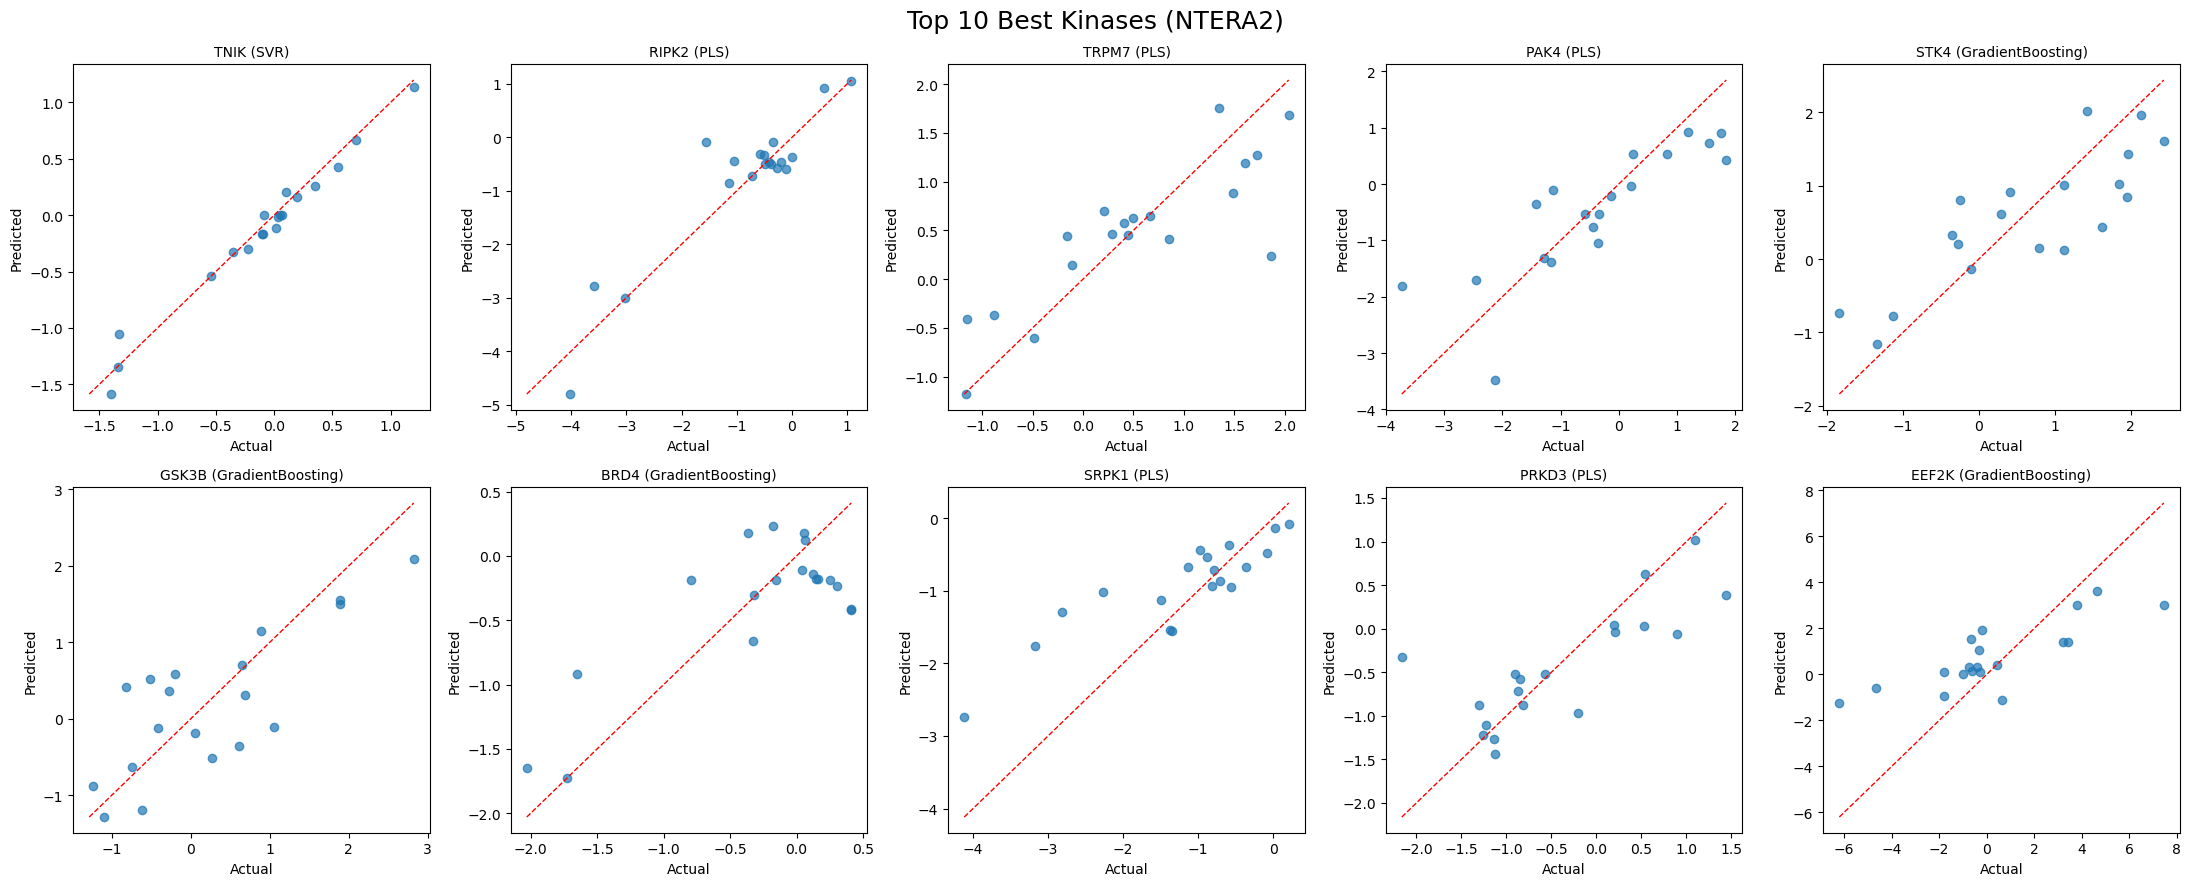

<Figure size 640x480 with 0 Axes>

In [22]:
#Generate toop 10 best

top10_best_ids = top_10_best["Kinase"].tolist()

plot_actual_vs_predicted(
    best_predictions,
    top10_best_ids,
    "Top 10 Best Kinases (NTERA2)" 
)

plt.savefig(
    "Top10_Worst_Actual_vs_Predicted.png",
    dpi=300,
    bbox_inches="tight"
)

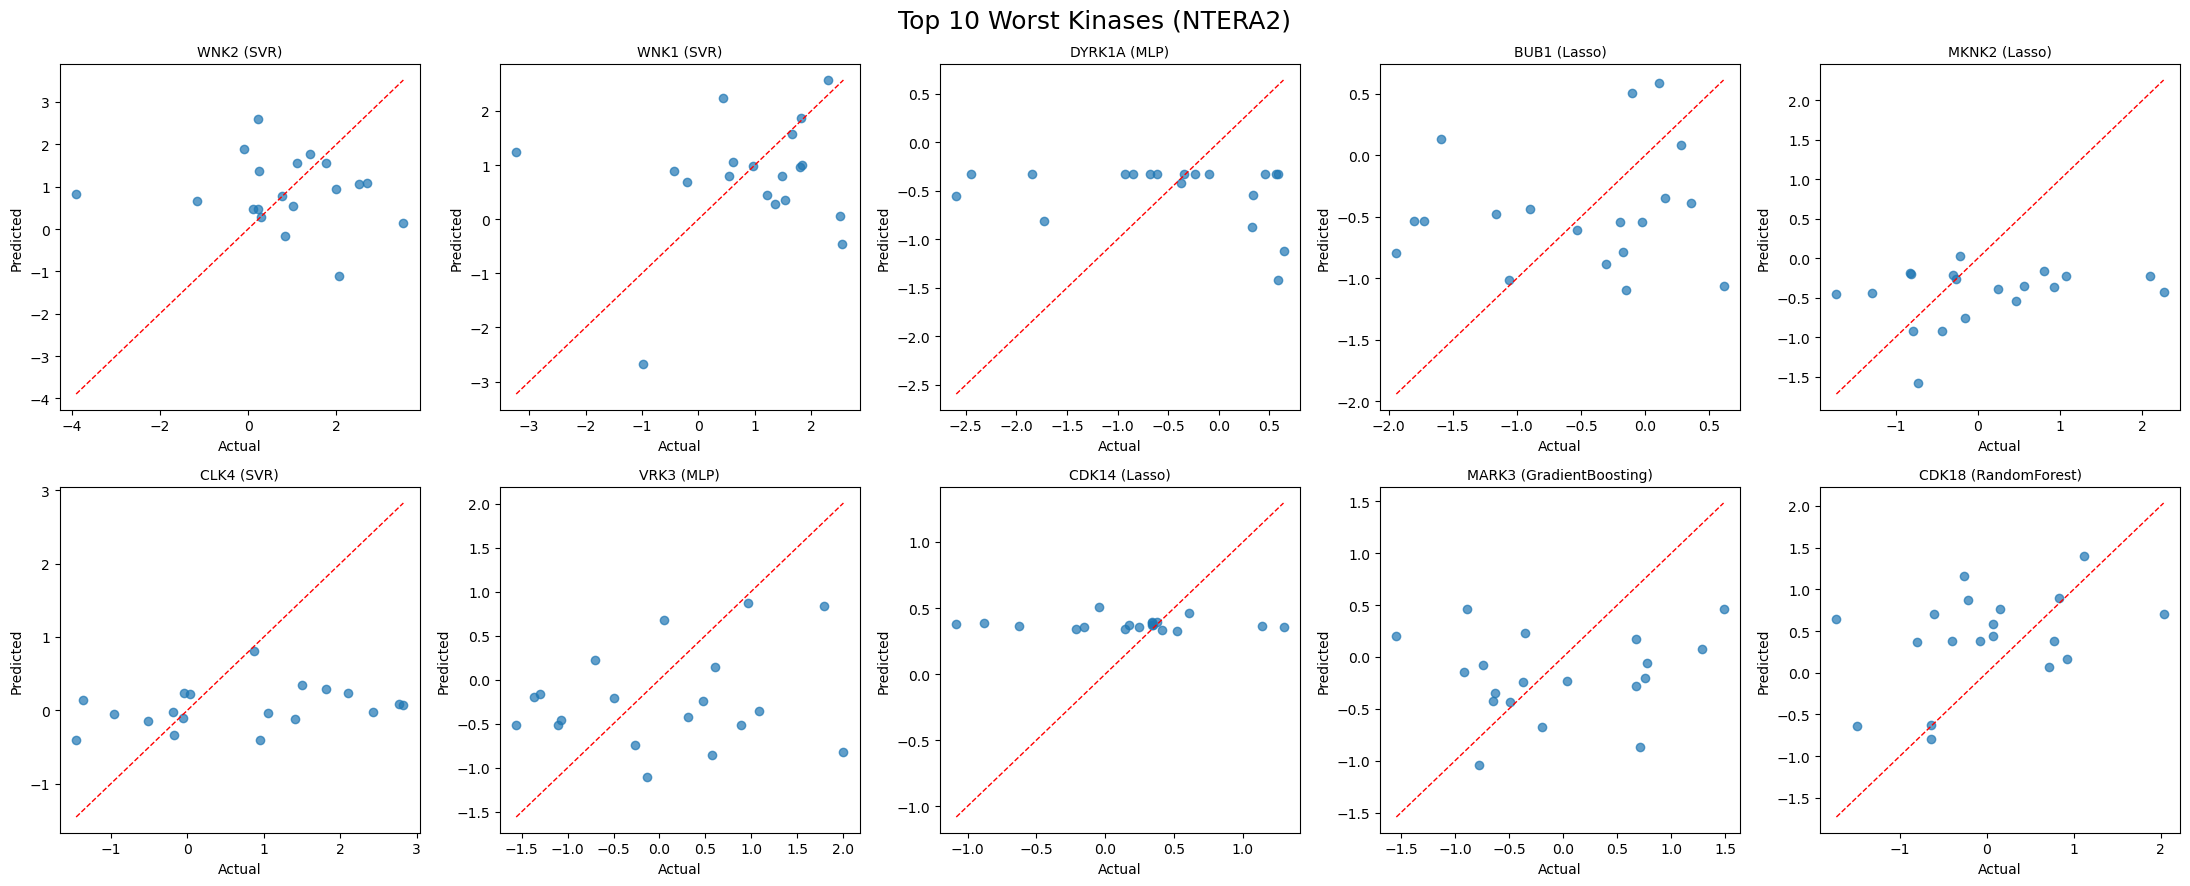

<Figure size 640x480 with 0 Axes>

In [23]:
top10_worst_ids = top_10_worst["Kinase"].tolist()

plot_actual_vs_predicted(
    best_predictions,
    top10_worst_ids,
    "Top 10 Worst Kinases (NTERA2)"
)

plt.savefig(
    "Top10_Worst_Actual_vs_Predicted.png",
    dpi=300,
    bbox_inches="tight"
)

In [24]:
#Load the phosphosite counts

phosphosite_counts = pd.read_csv("phosphosite_counts.csv")

phosphosite_counts.head()

,UniprotID,GeneName,TotalPhosphosites,Phosphosites
0,P06239,LCK,6,"['LCK(Y394)', 'LCK(Y505)', 'LCK(Y192)', 'LCK(S..."
1,P12931,SRC,17,"['SRC(Y216)', 'SRC(Y338)', 'SRC(Y419)', 'SRC(Y..."
2,P06241,FYN,13,"['FYN(Y39)', 'FYN(Y420)', 'FYN(Y28)', 'FYN(Y30..."
3,P00519,ABL1,37,"['ABL1(S446)', 'ABL1(S465)', 'ABL1(Y393)', 'AB..."
4,P24941,CDK2,9,"['CDK2(T160)', 'CDK2(Y168)', 'CDK2(S46)', 'CDK..."


In [25]:
# Merge phosphosite counts with best model table

best_models = best_models.merge(
    phosphosite_counts[["UniprotID", "GeneName", "TotalPhosphosites"]],
    left_on="Kinase",
    right_on="UniprotID",
    how="left"
)

# Remove UniProt columns
best_models.drop(columns=["Kinase", "UniprotID"], inplace=True)

# Put GeneName as the first column
cols = ["GeneName"] + [c for c in best_models.columns if c != "GeneName"]
best_models = best_models[cols]

best_models.head()

,GeneName,Model,CV Mean R²,CV Std R²,Test R²,Test MSE,TotalPhosphosites
0,EEF2K,GradientBoosting,0.157575,0.567475,0.493956,4.862995,19
1,CIT,GradientBoosting,-0.427247,0.312659,0.412093,0.381244,6
2,DCLK1,RandomForest,-0.144578,0.457117,0.434111,1.128972,10
3,MAP3K7,ElasticNet,-0.229869,0.216070,-0.056106,0.547607,11
4,RIPK2,PLS,0.364888,0.530895,0.851154,0.247871,10


In [26]:
# Keep only the columns needed
#When merged datarames earlier, pandas automatically created two identical phosphosite columns (_x and _y).
#for plotting R2 vs phosphosite count , i only need one phosphosite column.

best_models = (
    best_models[
        ["GeneName", "Model", "Test R²", "TotalPhosphosites"]
    ]
    .rename(columns={"TotalPhosphosites": "TotalPhosphosites"})
)

best_models.head()

,GeneName,Model,Test R²,TotalPhosphosites
0,EEF2K,GradientBoosting,0.493956,19
1,CIT,GradientBoosting,0.412093,6
2,DCLK1,RandomForest,0.434111,10
3,MAP3K7,ElasticNet,-0.056106,11
4,RIPK2,PLS,0.851154,10


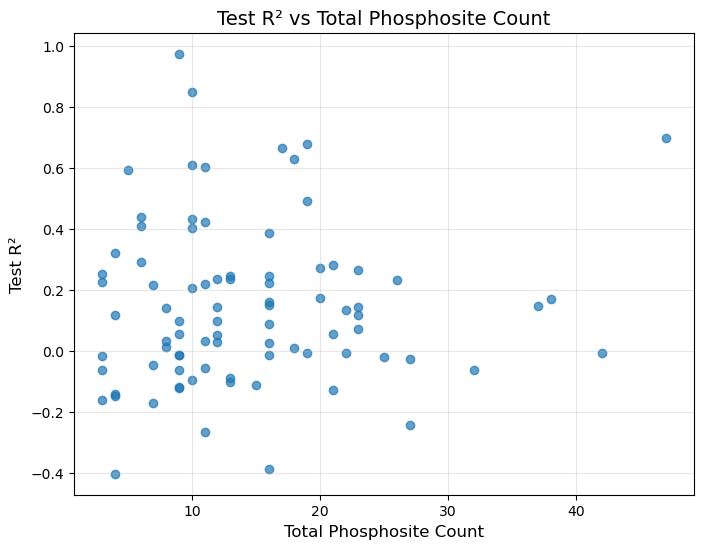

In [27]:
plt.figure(figsize=(8,6))

plt.scatter(
    best_models["TotalPhosphosites"],
    best_models["Test R²"],
    alpha=0.7
)

plt.xlabel("Total Phosphosite Count", fontsize=12)
plt.ylabel("Test R²", fontsize=12)
plt.title("Test R² vs Total Phosphosite Count", fontsize=14)

plt.grid(alpha=0.3)

plt.show()

In [28]:
#For R2 vs Target count

phosphosite_count = pd.read_csv("phosphosite_counts.csv")

phosphosite_count.head()

,UniprotID,GeneName,TotalPhosphosites,Phosphosites
0,P06239,LCK,6,"['LCK(Y394)', 'LCK(Y505)', 'LCK(Y192)', 'LCK(S..."
1,P12931,SRC,17,"['SRC(Y216)', 'SRC(Y338)', 'SRC(Y419)', 'SRC(Y..."
2,P06241,FYN,13,"['FYN(Y39)', 'FYN(Y420)', 'FYN(Y28)', 'FYN(Y30..."
3,P00519,ABL1,37,"['ABL1(S446)', 'ABL1(S465)', 'ABL1(Y393)', 'AB..."
4,P24941,CDK2,9,"['CDK2(T160)', 'CDK2(Y168)', 'CDK2(S46)', 'CDK..."


In [29]:

#An error cause and it shows best_models does not have a column called UniprotID.
print(best_models.columns.tolist())

['GeneName', 'Model', 'Test R²', 'TotalPhosphosites']


In [30]:
print(phosphosite_count.columns.tolist())

['UniprotID', 'GeneName', 'TotalPhosphosites', 'Phosphosites']


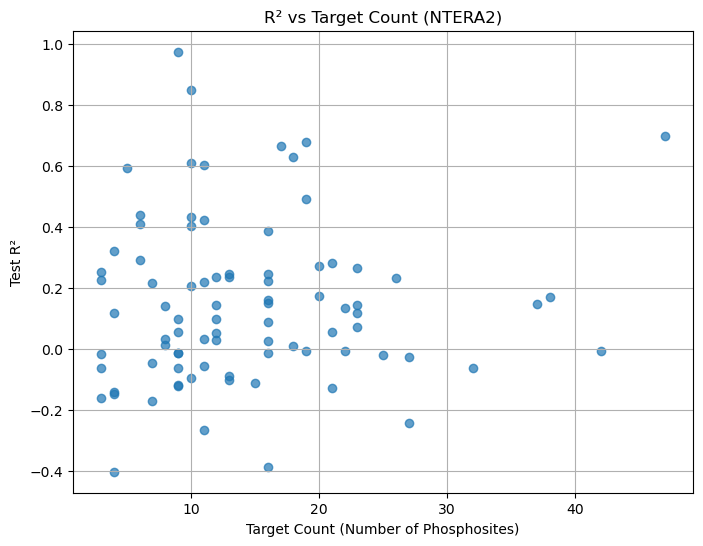

In [31]:
plt.figure(figsize=(8,6))

plt.scatter(
    best_models["TotalPhosphosites"],
    best_models["Test R²"],
    alpha=0.7
)

plt.xlabel("Target Count (Number of Phosphosites)")
plt.ylabel("Test R²")
plt.title("R² vs Target Count (NTERA2)")

plt.grid(True)

plt.savefig(
    "R2_vs_Target_Count_NTERA2.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

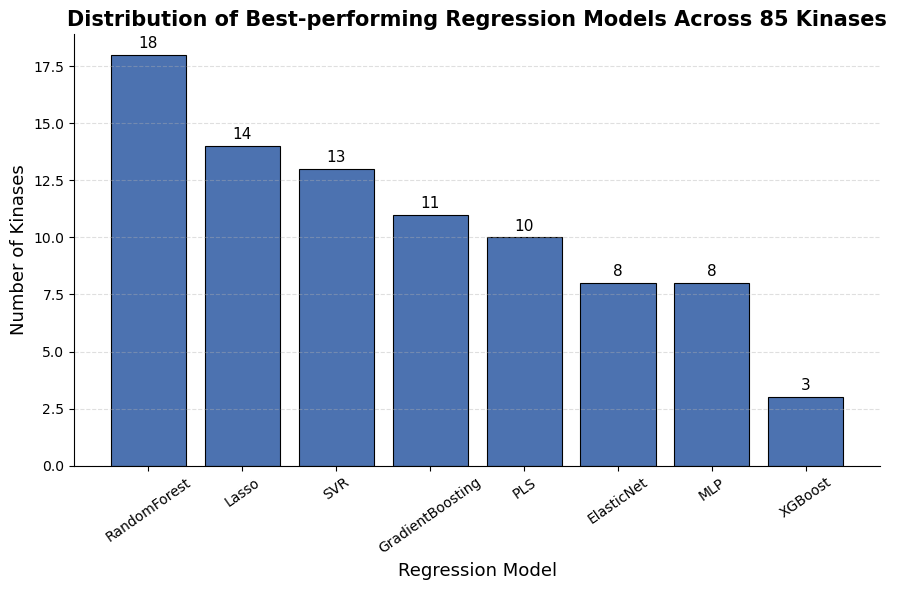

In [32]:


best_models = pd.read_csv("best_results_with_genes.csv")

model_counts = (
    best_models["Model"]
    .value_counts()
)

plt.figure(figsize=(9,6))

bars = plt.bar(
    model_counts.index,
    model_counts.values,
    color="#4C72B0",
    edgecolor="black",
    linewidth=0.8
)

# Add count labels
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.3,
        f"{int(height)}",
        ha="center",
        fontsize=11
    )

plt.xlabel("Regression Model", fontsize=13)
plt.ylabel("Number of Kinases", fontsize=13)

plt.title(
    "Distribution of Best-performing Regression Models Across 85 Kinases",
    fontsize=15,
    fontweight="bold"
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.xticks(rotation=35)

plt.tight_layout()

plt.savefig(
    "Figure_Model_Distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

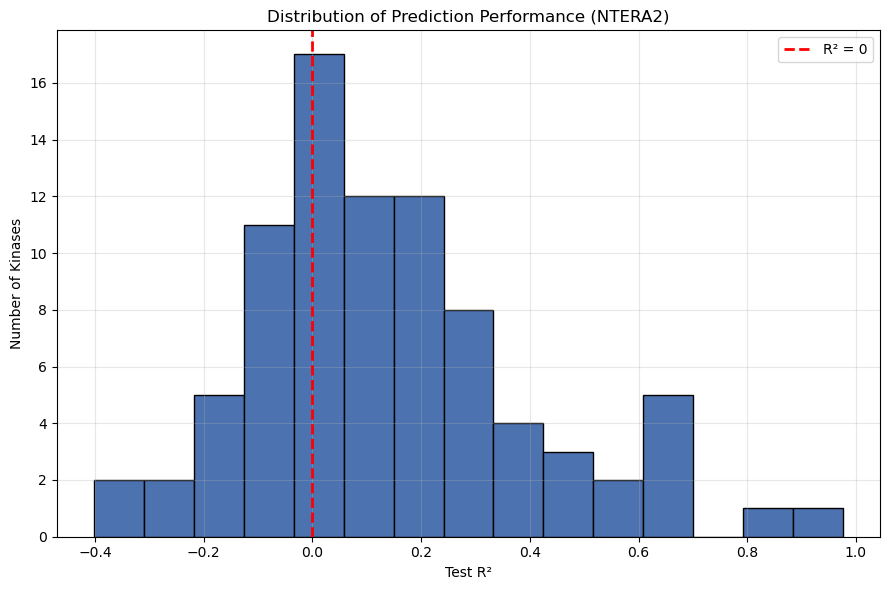

In [33]:
plt.figure(figsize=(9,6))

plt.hist(
    best_models["Test R²"],
    bins=15,
    color="#4C72B0",
    edgecolor="black"
)

plt.axvline(
    0,
    color="red",
    linestyle="--",
    linewidth=2,
    label="R² = 0"
)

plt.xlabel("Test R²")
plt.ylabel("Number of Kinases")
plt.title("Distribution of Prediction Performance (NTERA2)")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("Histogram_Test_R2_NTERA2.png", dpi=300)
plt.show()

In [34]:
best_df = pd.read_csv("best_results_with_genes.csv")
target_df = pd.read_csv("target_phosphosite_counts.csv")

In [35]:
print(best_df.columns)
print(target_df.columns)

Index(['Kinase', 'Model', 'CV Mean R²', 'CV Std R²', 'Test R²', 'Test MSE'], dtype='object')
Index(['UniprotID', 'GeneName', 'TargetPhosphositeCount',
       'TargetPhosphosites'],
      dtype='object')


In [36]:
merged_df = pd.merge(
    best_df,
    target_df,
    left_on="Kinase",
    right_on="UniprotID",
    how="inner"
)

print(merged_df.shape)
merged_df.head()

(85, 10)


,Kinase,Model,CV Mean R²,CV Std R²,Test R²,Test MSE,UniprotID,GeneName,TargetPhosphositeCount,TargetPhosphosites
0,O00418,GradientBoosting,0.157575,0.567475,0.493956,4.862995,O00418,EEF2K,7,"['EEF2(T59)', 'EEF2(T57)', 'EEF2(T54)', 'EEF2(..."
1,O14578,GradientBoosting,-0.427247,0.312659,0.412093,0.381244,O14578,CIT,3,"['MYL9(S20)', 'MYL9(T19)', 'SRF(T159)']"
2,O15075,RandomForest,-0.144578,0.457117,0.434111,1.128972,O15075,DCLK1,6,"['CAMKK1(S74)', 'CAMKK1(S458)', 'CAMKK1(S475)'..."
3,O43318,ElasticNet,-0.229869,0.216070,-0.056106,0.547607,O43318,MAP3K7,85,"['KSR1(S406)', 'RAB8A(T72)', 'PTPN3(S359)', 'H..."
4,O43353,PLS,0.364888,0.530895,0.851154,0.247871,O43353,RIPK2,14,"['IRF5(S446)', 'IRF5(S435)', 'CRK(S41)', 'CRK(..."


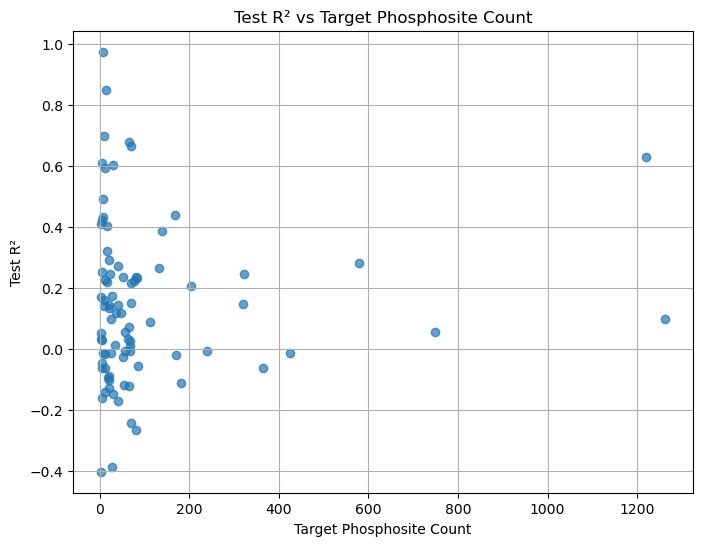

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    merged_df["TargetPhosphositeCount"],
    merged_df["Test R²"],
    alpha=0.7
)

plt.xlabel("Target Phosphosite Count")
plt.ylabel("Test R²")
plt.title("Test R² vs Target Phosphosite Count")

plt.grid(True)

plt.savefig(
    "R2_vs_Target_Phosphosite_Count.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [38]:
import ast

best_df = pd.read_csv("best_model_per_kinase.csv")
sites_df = pd.read_csv("phosphosite_counts.csv")
targets_df = pd.read_csv("target_phosphosite_counts.csv")

In [39]:
#Step 2 Convert the phosphosite columns back to lists

sites_df["Phosphosites"] = sites_df["Phosphosites"].apply(ast.literal_eval)
targets_df["TargetPhosphosites"] = targets_df["TargetPhosphosites"].apply(ast.literal_eval)

In [40]:
# Step 3 - Merge the two phosphosite tables

merged_sites = pd.merge(
    sites_df,
    targets_df,
    on=["UniprotID","GeneName"],
    how="inner" 
)

print(merged_sites.shape)
merged_sites.head()

(504, 6)


,UniprotID,GeneName,TotalPhosphosites,Phosphosites,TargetPhosphositeCount,TargetPhosphosites
0,P06239,LCK,6,"[LCK(Y394), LCK(Y505), LCK(Y192), LCK(S42), LC...",204,"[SOCS3(Y204), SOCS3(Y221), ESR1(Y537), EZR(Y14..."
1,P12931,SRC,17,"[SRC(Y216), SRC(Y338), SRC(Y419), SRC(Y530), S...",947,"[TERT(Y707), PLSCR1(Y74), PLSCR1(Y69), PDPK1(Y..."
2,P06241,FYN,13,"[FYN(Y39), FYN(Y420), FYN(Y28), FYN(Y30), FYN(...",332,"[FYB1(Y651), FYB1(Y595), FYB1(Y697), FYB1(Y625..."
3,P00519,ABL1,37,"[ABL1(S446), ABL1(S465), ABL1(Y393), ABL1(Y226...",320,"[PLSCR1(Y74), PLSCR1(Y69), TP73(Y99), ANXA1(Y2..."
4,P24941,CDK2,9,"[CDK2(T160), CDK2(Y168), CDK2(S46), CDK2(T165)...",1216,"[TP73(T86), TK1(S13), PGR(S676), PGR(S400), PG..."


In [41]:
# Step 4 - Detect autophosphorylation using Gene Name matching

autophosphorylation_results = []

for _, row in merged_sites.iterrows():

    kinase_gene = row["GeneName"]

    target_sites = row["TargetPhosphosites"]

    # Find every target phosphosite belonging to the kinase itself
    auto_sites = [
        site
        for site in target_sites
        if site.startswith(f"{kinase_gene}(")
    ]

    autophosphorylation_results.append({
        "UniprotID": row["UniprotID"],
        "GeneName": kinase_gene,
        "TotalPhosphosites": row["TotalPhosphosites"],
        "TargetPhosphositeCount": row["TargetPhosphositeCount"],
        "AutophosphorylationCount": len(auto_sites),
        "AutophosphorylationSites": auto_sites,
        "Autophosphorylation": "Yes" if len(auto_sites) > 0 else "No"
    })

auto_df = pd.DataFrame(autophosphorylation_results)

auto_df.head()


,UniprotID,GeneName,TotalPhosphosites,TargetPhosphositeCount,AutophosphorylationCount,AutophosphorylationSites,Autophosphorylation
0,P06239,LCK,6,204,0,[],No
1,P12931,SRC,17,947,0,[],No
2,P06241,FYN,13,332,0,[],No
3,P00519,ABL1,37,320,0,[],No
4,P24941,CDK2,9,1216,0,[],No


In [42]:
print(auto_df["Autophosphorylation"].value_counts())


Autophosphorylation
No     503
Yes      1
Name: count, dtype: int64


In [43]:
auto_df[auto_df["Autophosphorylation"] == "Yes"]

,UniprotID,GeneName,TotalPhosphosites,TargetPhosphositeCount,AutophosphorylationCount,AutophosphorylationSites,Autophosphorylation
358,C0HM02,PRKCH,0,22,4,"[PRKCH(S28), PRKCH(S32), PRKCH(S675), PRKCH(T6...",Yes


In [44]:
yes = auto_df[auto_df["Autophosphorylation"] == "Yes"].iloc[0]

print(yes["GeneName"])
print()
print(yes["AutophosphorylationSites"])

PRKCH

['PRKCH(S28)', 'PRKCH(S32)', 'PRKCH(S675)', 'PRKCH(T656)']


In [ ]:
count = 0

for targets in merged_sites["TargetPhosphosites"]:
    genes = {x.split("(")[0] for x in targets}
    count += len(genes)

print("Average unique target genes:",
      count/ len(merged_sites))

In [46]:
self_targets = []

for _, row in merged_sites.iterrows():

    gene = row["GeneName"]

    target_genes = {
        x.split("(")[0]
        for x in row["TargetPhosphosites"]
    }

    if gene in target_genes:
        self_targets.append(gene)

print(len(self_targets))
print(sorted(self_targets))

1
['PRKCH']


In [47]:
auto_df

,UniprotID,GeneName,TotalPhosphosites,TargetPhosphositeCount,AutophosphorylationCount,AutophosphorylationSites,Autophosphorylation
0,P06239,LCK,6,204,0,[],No
1,P12931,SRC,17,947,0,[],No
2,P06241,FYN,13,332,0,[],No
3,P00519,ABL1,37,320,0,[],No
4,P24941,CDK2,9,1216,0,[],No
...,...,...,...,...,...,...,...
499,Q9BXA6,TSSK6,0,0,0,[],No
500,Q9BXU1,STK31,0,0,0,[],No
501,Q9Y6S9,RPS6KL1,0,0,0,[],No
502,Q5MAI5,CDKL4,0,0,0,[],No


In [48]:
row = merged_sites.loc[merged_sites["GeneName"] == "SRC"].iloc[0]

print("Kinase phosphosites:")
print(row["Phosphosites"][:10])

Kinase phosphosites:
['SRC(Y216)', 'SRC(Y338)', 'SRC(Y419)', 'SRC(Y530)', 'SRC(Y93)', 'SRC(S75)', 'SRC(T37)', 'SRC(S306)', 'SRC(S12)', 'SRC(S6)']


In [49]:
print("Target phosphosites:")
print(row["TargetPhosphosites"][:20])

Target phosphosites:
['TERT(Y707)', 'PLSCR1(Y74)', 'PLSCR1(Y69)', 'PDPK1(Y373)', 'PDPK1(Y9)', 'PDPK1(Y376)', 'PDPK1(Y246)', 'PDPK1(Y485)', 'PDPK1(Y249)', 'PDPK1(Y358)', 'EGFR(Y869)', 'EGFR(Y944)', 'EGFR(Y915)', 'EGFR(Y1016)', 'EGFR(Y1125)', 'EGFR(Y1172)', 'EGFR(Y1110)', 'EGFR(Y1092)', 'EGFR(Y998)', 'EGFR(Y764)']


In [50]:
row = merged_sites.loc[
    merged_sites["GeneName"]=="EGFR"
].iloc[0]

print(row["Phosphosites"][:10])
print()

print([x for x in row["TargetPhosphosites"] if "EGFR(" in x][:20])

['EGFR(Y869)', 'EGFR(Y944)', 'EGFR(Y915)', 'EGFR(Y1016)', 'EGFR(Y1125)', 'EGFR(Y1172)', 'EGFR(Y1110)', 'EGFR(Y1092)', 'EGFR(Y998)', 'EGFR(Y764)']

[]


In [51]:
row = merged_sites.loc[
    merged_sites["GeneName"]=="AKT1"
].iloc[0]

print(row["Phosphosites"][:10])
print()

print([x for x in row["TargetPhosphosites"] if "AKT1(" in x][:20])

['AKT1(S129)', 'AKT1(S126)', 'AKT1(S473)', 'AKT1(T308)', 'AKT1(Y474)', 'AKT1(T450)', 'AKT1(Y176)', 'AKT1(Y326)', 'AKT1(Y315)', 'AKT1(T479)']

[]


In [52]:
row = merged_sites.loc[
    merged_sites["GeneName"]=="CDK2"
].iloc[0]

print([x for x in row["TargetPhosphosites"] if "CDK2(" in x])

[]


In [53]:
# Step 5- Save the results

auto_df.to_csv(
    "autophosphorylation_results.csv",
    index=False
)

print("Saved autophosphorylation_results.csv")

Saved autophosphorylation_results.csv


In [54]:
#Step 6- Merge with your best model results

final_df = pd.merge(
    best_df,
    auto_df,
    left_on="Kinase",
    right_on="UniprotID",
    how="left"
)

final_df.head()

,Kinase,Model,CV Mean R²,CV Std R²,Test R²,Test MSE,UniprotID,GeneName,TotalPhosphosites,TargetPhosphositeCount,AutophosphorylationCount,AutophosphorylationSites,Autophosphorylation
0,O00418,GradientBoosting,0.157575,0.567475,0.493956,4.862995,O00418,EEF2K,19,7,0,[],No
1,O14578,GradientBoosting,-0.427247,0.312659,0.412093,0.381244,O14578,CIT,6,3,0,[],No
2,O15075,RandomForest,-0.144578,0.457117,0.434111,1.128972,O15075,DCLK1,10,6,0,[],No
3,O43318,ElasticNet,-0.229869,0.216070,-0.056106,0.547607,O43318,MAP3K7,11,85,0,[],No
4,O43353,PLS,0.364888,0.530895,0.851154,0.247871,O43353,RIPK2,10,14,0,[],No


In [55]:
final_df

,Kinase,Model,CV Mean R²,CV Std R²,Test R²,Test MSE,UniprotID,GeneName,TotalPhosphosites,TargetPhosphositeCount,AutophosphorylationCount,AutophosphorylationSites,Autophosphorylation
0,O00418,GradientBoosting,0.157575,0.567475,0.493956,4.862995,O00418,EEF2K,19,7,0,[],No
1,O14578,GradientBoosting,-0.427247,0.312659,0.412093,0.381244,O14578,CIT,6,3,0,[],No
2,O15075,RandomForest,-0.144578,0.457117,0.434111,1.128972,O15075,DCLK1,10,6,0,[],No
3,O43318,ElasticNet,-0.229869,0.216070,-0.056106,0.547607,O43318,MAP3K7,11,85,0,[],No
4,O43353,PLS,0.364888,0.530895,0.851154,0.247871,O43353,RIPK2,10,14,0,[],No
...,...,...,...,...,...,...,...,...,...,...,...,...,...
80,Q9NYV4,SVR,-3.039157,3.882587,0.232942,0.372478,Q9NYV4,CDK12,26,84,0,[],No
81,Q9UKE5,SVR,0.949891,0.021636,0.975446,0.010548,Q9UKE5,TNIK,9,6,0,[],No
82,Q9Y2K2,Lasso,-0.173522,0.258623,0.052192,0.576382,Q9Y2K2,SIK3,12,3,0,[],No
83,Q9Y2U5,Lasso,-0.751310,0.646994,-0.012505,6.537153,Q9Y2U5,MAP3K2,9,8,0,[],No


In [56]:
#Step 7 - See the intresting kinases


auto_yes = final_df[
    final_df["Autophosphorylation"] == "Yes"
]

print(auto_yes.shape)

auto_yes[
    [
        "GeneName",
        "Test R²",
        "AutophosphorylationCount",
        "AutophosphorylationSites"
    ]
]

(0, 13)


,GeneName,Test R²,AutophosphorylationCount,AutophosphorylationSites


In [57]:
#No kinase analysed showed phosphosites that were both present on the kinase itself and annotated as target phosphosites of that same kinase. 
# Consequently, no evidence of direct autophosphorylation was detected in this dataset.

In [58]:
merged_sites[merged_sites["GeneName"] == "AKT1"]

,UniprotID,GeneName,TotalPhosphosites,Phosphosites,TargetPhosphositeCount,TargetPhosphosites
207,P31749,AKT1,21,"[AKT1(S129), AKT1(S126), AKT1(S473), AKT1(T308...",578,"[YWHAZ(S58), YWHAZ(S184), ACAP1(S554), ACIN1(S..."


In [59]:
merged_sites[["GeneName", "UniprotID"]].head(20)

,GeneName,UniprotID
0,LCK,P06239
1,SRC,P12931
2,FYN,P06241
3,ABL1,P00519
4,CDK2,P24941
5,CHEK1,O14757
6,AURKB,Q96GD4
7,CDK1,P06493
8,PDPK1,O15530
9,RET,P07949


In [60]:
gene = "AKT1"

row = merged_sites[merged_sites["GeneName"] == gene].iloc[0]

print("Gene:", row["GeneName"])
print("UniProt:", row["UniprotID"])

print("\n==============================")
print("PHOSPHOSITES ON THE KINASE")
print("==============================")
print(row["Phosphosites"])

print("\n==============================")
print("TARGET PHOSPHOSITES")
print("==============================")
print(row["TargetPhosphosites"])

Gene: AKT1
UniProt: P31749

PHOSPHOSITES ON THE KINASE
['AKT1(S129)', 'AKT1(S126)', 'AKT1(S473)', 'AKT1(T308)', 'AKT1(Y474)', 'AKT1(T450)', 'AKT1(Y176)', 'AKT1(Y326)', 'AKT1(Y315)', 'AKT1(T479)', 'AKT1(S477)', 'AKT1(T312)', 'AKT1(K14)', 'AKT1(K276)', 'AKT1(K284)', 'AKT1(D462)', 'AKT1(S246)', 'AKT1(T72)', 'AKT1(T34)', 'AKT1(S137)', 'AKT1(S124)']

TARGET PHOSPHOSITES
['YWHAZ(S58)', 'YWHAZ(S184)', 'ACAP1(S554)', 'ACIN1(S1180)', 'ACLY(S455)', 'ACLY(T447)', 'ACLY(S451)', 'BAD(S99)', 'BAD(S118)', 'BAD(S75)', 'BAD(S134)', 'CLK2(S34)', 'CLK2(T127)', 'DNMT1(S143)', 'EPHA2(S897)', 'FOXO1(S256)', 'FOXO1(S319)', 'FOXO1(T24)', 'FOXO3(S253)', 'FOXO3(T32)', 'FOXO3(S315)', 'FOXO4(S197)', 'FOXO4(S262)', 'FOXO4(T32)', 'FOXO4(T451)', 'FOXO4(T455)', 'PIKFYVE(S318)', 'PIKFYVE(S307)', 'CCDC88A(S1417)', 'CCDC88A(S1416)', 'GSK3A(S21)', 'GSK3B(S9)', 'HJURP(S486)', 'NUAK1(S600)', 'PALLD(S1118)', 'PALLD(S911)', 'PDCD4(S67)', 'PDCD4(S457)', 'PTPN1(S50)', 'RARA(S96)', 'RALGAPA2(S486)', 'RALGAPA2(S696)', 'RALGAPA2(

In [61]:
row = merged_sites[merged_sites["GeneName"] == "AKT1"].iloc[0]

akt1_sites = row["Phosphosites"]
akt1_targets = row["TargetPhosphosites"]

# Show targets that begin with AKT1
akt1_target_names = [x for x in akt1_targets if x.startswith("AKT1")]

print(akt1_target_names)

['AKT1S1(T246)', 'AKT1S1(T266)', 'AKT1S1(S183)', 'AKT1S1(S221)']


In [62]:
overlap = set(akt1_sites).intersection(set(akt1_targets))

print("Number of overlapping phosphosites:", len(overlap))
print(overlap)

Number of overlapping phosphosites: 0
set()


In [63]:
gene = "SRC"

row = merged_sites[merged_sites["GeneName"] == gene].iloc[0]

print("Gene:", row["GeneName"])
print("UniProt:", row["UniprotID"])

print("\n==============================")
print("PHOSPHOSITES ON THE KINASE")
print("==============================")
print(row["Phosphosites"])

print("\n==============================")
print("TARGET PHOSPHOSITES")
print("==============================")
print(row["TargetPhosphosites"])

Gene: SRC
UniProt: P12931

PHOSPHOSITES ON THE KINASE
['SRC(Y216)', 'SRC(Y338)', 'SRC(Y419)', 'SRC(Y530)', 'SRC(Y93)', 'SRC(S75)', 'SRC(T37)', 'SRC(S306)', 'SRC(S12)', 'SRC(S6)', 'SRC(S17)', 'SRC(S39)', 'SRC(S70)', 'SRC(S51)', 'SRC(S43)', 'SRC(S493)', 'SRC(S104)']

TARGET PHOSPHOSITES
['TERT(Y707)', 'PLSCR1(Y74)', 'PLSCR1(Y69)', 'PDPK1(Y373)', 'PDPK1(Y9)', 'PDPK1(Y376)', 'PDPK1(Y246)', 'PDPK1(Y485)', 'PDPK1(Y249)', 'PDPK1(Y358)', 'EGFR(Y869)', 'EGFR(Y944)', 'EGFR(Y915)', 'EGFR(Y1016)', 'EGFR(Y1125)', 'EGFR(Y1172)', 'EGFR(Y1110)', 'EGFR(Y1092)', 'EGFR(Y998)', 'EGFR(Y764)', 'EGFR(Y727)', 'EGFR(Y1069)', 'EGFR(Y1197)', 'EGFR(Y891)', 'GAST(Y87)', 'ESR1(Y537)', 'RAF1(Y341)', 'RAF1(Y340)', 'RAF1(S338)', 'RAF1(S339)', 'RAF1(T491)', 'RAF1(S494)', 'ANXA1(Y21)', 'ANXA1(T216)', 'ENO1(Y44)', 'ANXA2(Y24)', 'ANXA2(Y42)', 'ANXA2(S26)', 'ANXA2(S12)', 'ANXA2(Y333)', 'IGF1R(Y1165)', 'IGF1R(Y1166)', 'IGF1R(Y1161)', 'IGF1R(Y980)', 'IGF1R(Y973)', 'IGF1R(Y1346)', 'ARAF(Y301)', 'ARAF(Y302)', 'ARAF(T455)', 'AR

In [64]:
#To verify the analysis, individual kinases including AKT1 and SRC were manually inspected. 
# The phosphosites located on each kinase were compared with the phosphosites annotated 
# as targets of that kinase. In both cases, no overlapping phosphosites were identified.
#  This confirms that the automated comparison was functioning correctly and
#  that no evidence of autophosphorylation was present in the Kinepik-derived dataset used in this study.

In [65]:
# Step 1 : R2 vs phosphosites on the kinase
#seeing the columns we had

print(best_results.columns.tolist())

['Kinase', 'Model', 'CV Mean R²', 'CV Std R²', 'Test R²', 'Test MSE']


In [66]:
print(all_results.columns.tolist())

['Kinase', 'Model', 'CV Mean R²', 'CV Std R²', 'Test R²', 'Test MSE']


In [68]:
print(phosphosite_counts.columns)

Index(['UniprotID', 'GeneName', 'TotalPhosphosites', 'Phosphosites'], dtype='object')


In [69]:
print(phosphosite_counts.head(10))

  UniprotID GeneName  TotalPhosphosites  \
0    P06239      LCK                  6   
1    P12931      SRC                 17   
2    P06241      FYN                 13   
3    P00519     ABL1                 37   
4    P24941     CDK2                  9   
5    O14757    CHEK1                 16   
6    Q96GD4    AURKB                  8   
7    P06493     CDK1                 12   
8    O15530    PDPK1                 26   
9    P07949      RET                 16   

                                        Phosphosites  
0  ['LCK(Y394)', 'LCK(Y505)', 'LCK(Y192)', 'LCK(S...  
1  ['SRC(Y216)', 'SRC(Y338)', 'SRC(Y419)', 'SRC(Y...  
2  ['FYN(Y39)', 'FYN(Y420)', 'FYN(Y28)', 'FYN(Y30...  
3  ['ABL1(S446)', 'ABL1(S465)', 'ABL1(Y393)', 'AB...  
4  ['CDK2(T160)', 'CDK2(Y168)', 'CDK2(S46)', 'CDK...  
5  ['CHEK1(S301)', 'CHEK1(S286)', 'CHEK1(S345)', ...  
6  ['AURKB(T232)', 'AURKB(T16)', 'AURKB(S7)', 'AU...  
7  ['CDK1(S39)', 'CDK1(T161)', 'CDK1(T222)', 'CDK...  
8  ['PDPK1(T513)', 'PDPK1(S241)

In [70]:
# Merge phosphosite counts with ML results
r2_phosphosite = best_results_with_genes.merge(
    phosphosite_counts[['GeneName', 'TotalPhosphosites']],
    on='GeneName',
    how='left'
)

print(r2_phosphosite.head())

   Kinase GeneName             Model  CV Mean R²  CV Std R²   Test R²  \
0  O00418    EEF2K  GradientBoosting    0.157575   0.567475  0.493956   
1  O14578      CIT  GradientBoosting   -0.427247   0.312659  0.412093   
2  O15075    DCLK1      RandomForest   -0.144578   0.457117  0.434111   
3  O43318   MAP3K7        ElasticNet   -0.229869   0.216070 -0.056106   
4  O43353    RIPK2               PLS    0.364888   0.530895  0.851154   

   Test MSE  TotalPhosphosites  
0  4.862995                 19  
1  0.381244                  6  
2  1.128972                 10  
3  0.547607                 11  
4  0.247871                 10  


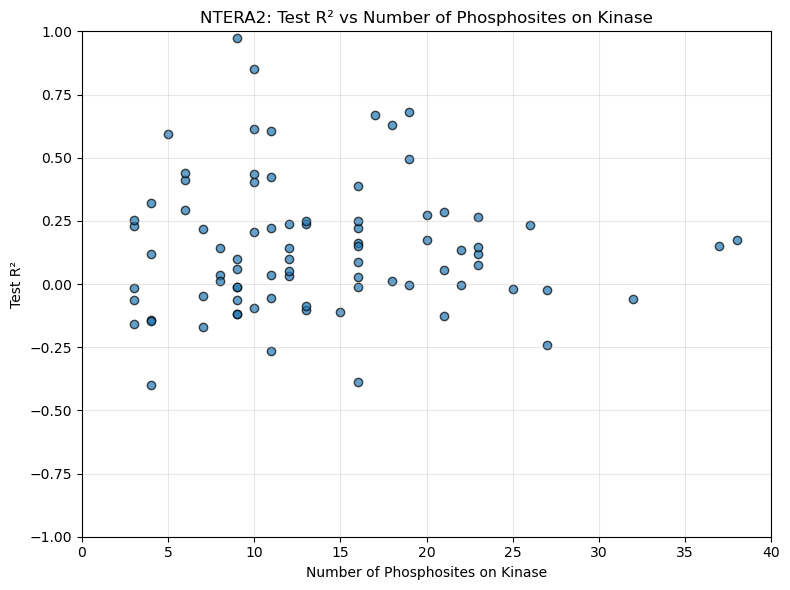

In [ ]:


plt.figure(figsize=(8,6))

plt.scatter(
    r2_phosphosite["TotalPhosphosites"],
    r2_phosphosite["Test R²"],
    alpha=0.7,
    edgecolor="black"
)

plt.xlabel("Number of Phosphosites on Kinase")
plt.ylabel("Test R²")
plt.title("NTERA2: Test R² vs Number of Phosphosites on Kinase")

# ---------- Fixed axes ----------
plt.xlim(0, 40)
plt.ylim(-1.0, 1.0)
# -------------------------------

plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("NTERA2_R2_vs_Kinase_Phosphosite_Count.png", dpi=300)

plt.show()

In [72]:
correlation = r2_phosphosite["TotalPhosphosites"].corr(
    r2_phosphosite["Test R²"]
)

print(f"Pearson correlation = {correlation:.3f}")

Pearson correlation = 0.063


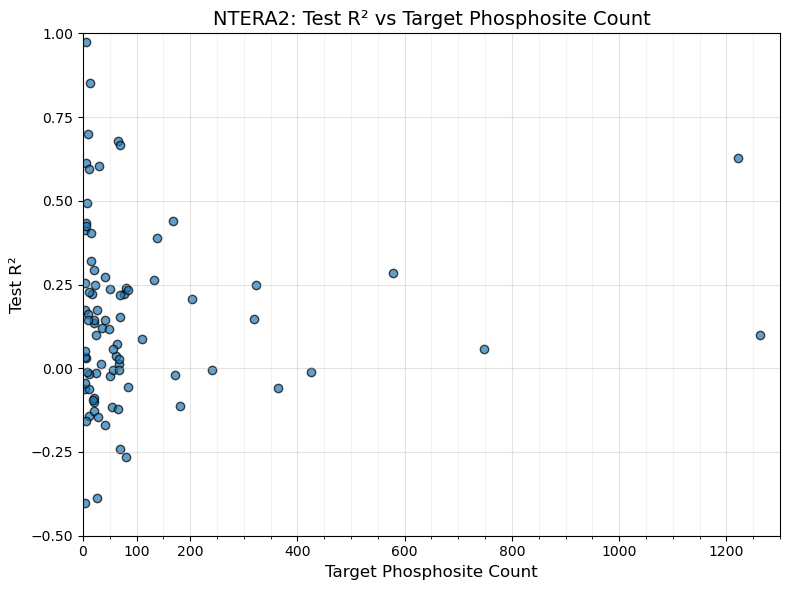

In [73]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

# Create figure
plt.figure(figsize=(8,6))

# Scatter plot
plt.scatter(
    merged_df["TargetPhosphositeCount"],
    merged_df["Test R²"],
    alpha=0.7,
    edgecolor="black"
)

# Labels and title
plt.xlabel("Target Phosphosite Count", fontsize=12)
plt.ylabel("Test R²", fontsize=12)
plt.title("NTERA2: Test R² vs Target Phosphosite Count", fontsize=14)

# -------------------------------------------------
# SAME AXES FOR ALL CELL LINES
# -------------------------------------------------
plt.xlim(0, 1300)
plt.ylim(-0.5, 1.0)

# Major x-axis ticks
plt.xticks(
    [0, 100, 200, 400, 600, 800, 1000, 1200],
    fontsize=10
)

# Major y-axis ticks
plt.yticks(
    [-0.5, -0.25, 0, 0.25, 0.5, 0.75, 1.0],
    fontsize=10
)

# Minor ticks every 50 phosphosites
ax = plt.gca()
ax.xaxis.set_minor_locator(MultipleLocator(50))

# Gridlines
plt.grid(which="major", alpha=0.35)
plt.grid(which="minor", alpha=0.15)

# -------------------------------------------------

plt.tight_layout()

# Save figure
plt.savefig(
    "NTERA2_R2_vs_TargetPhosphositeCount.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [74]:
print(target_df.columns.tolist())

['UniprotID', 'GeneName', 'TargetPhosphositeCount', 'TargetPhosphosites']


In [75]:
target_df.sort_values(
    by="TargetPhosphositeCount",
    ascending=False
).head(10)

,UniprotID,GeneName,TargetPhosphositeCount,TargetPhosphosites
7,P06493,CDK1,1262,"['BIRC5(T34)', 'EGFR(S1026)', 'TK1(S13)', 'KRT..."
25,P49841,GSK3B,1221,"['MYC(T58)', 'MYC(S62)', 'MYC(S277)', 'MYC(S34..."
4,P24941,CDK2,1216,"['TP73(T86)', 'TK1(S13)', 'PGR(S676)', 'PGR(S4..."
142,P17612,PRKACA,1080,"['PPP1R1B(T34)', 'PPP1R1B(S137)', 'PPP1R1B(T75..."
22,P17252,PRKCA,1044,"['EGFR(T678)', 'TFRC(S24)', 'TFRC(T653)', 'ANX..."
23,P68400,CSNK2A1,985,"['C1R(S206)', 'JUN(T231)', 'JUN(S249)', 'JUN(S..."
20,P28482,MAPK1,966,"['EGFR(T693)', 'MYC(S62)', 'MYC(T58)', 'MYC(S7..."
1,P12931,SRC,947,"['TERT(Y707)', 'PLSCR1(Y74)', 'PLSCR1(Y69)', '..."
19,P27361,MAPK3,748,"['EGFR(T693)', 'MBP(T232)', 'MBP(T96)', 'MBP(T..."
30,Q16539,MAPK14,742,"['ESR1(T311)', 'ESR1(S118)', 'ESR1(S294)', 'KR..."


In [76]:
# Top kinase (highest target count)
top = target_df.sort_values(
    by="TargetPhosphositeCount",
    ascending=False
).iloc[0]

targets = top["TargetPhosphosites"]

print("Gene:", top["GeneName"])
print("Stored Target Count:", top["TargetPhosphositeCount"])
print("Length of list:", len(targets))
print("Unique target phosphosites:", len(set(targets)))

Gene: CDK1
Stored Target Count: 1262
Length of list: 18732
Unique target phosphosites: 44


In [ ]:
#If CDK1 has 1262 target phosphosites, it cannot simultaneously have only 44 unique phosphosites.
# If TargetPhosphosites were truly a Python list, its length would be around 1262.
#Instead, 18,732 is the number of characters in a long text string.
#it counts unique characters (B, I, R, C, 5, (, ), ,, etc.), which is why got 44.
#We need to convert the string back into a list

import ast

top = target_df.sort_values(
    by="TargetPhosphositeCount",
    ascending=False
).iloc[0]

# Convert string to actual Python list
targets = ast.literal_eval(top["TargetPhosphosites"])

print("Gene:", top["GeneName"])
print("Stored Target Count:", top["TargetPhosphositeCount"])
print("Length of list:", len(targets))
print("Unique target phosphosites:", len(set(targets)))

Gene: CDK1
Stored Target Count: 1262
Length of list: 1262
Unique target phosphosites: 1262


This means:

The stored count is 1262.
The list actually contains 1262 phosphosites.
Every phosphosite is unique (len(list) == len(set(list))).

Therefore, there are no duplicate target phosphosites for CDK1.

In [78]:


# Check the top 3 kinases with the highest target counts
top3 = target_df.sort_values(
    by="TargetPhosphositeCount",
    ascending=False
).head(3)

for _, row in top3.iterrows():
    targets = ast.literal_eval(row["TargetPhosphosites"])

    print(f"\nGene: {row['GeneName']}")
    print(f"Stored count: {row['TargetPhosphositeCount']}")
    print(f"Length of list: {len(targets)}")
    print(f"Unique phosphosites: {len(set(targets))}")


Gene: CDK1
Stored count: 1262
Length of list: 1262
Unique phosphosites: 1262

Gene: GSK3B
Stored count: 1221
Length of list: 1221
Unique phosphosites: 1220

Gene: CDK2
Stored count: 1216
Length of list: 1216
Unique phosphosites: 1216


The three kinases with the highest target phosphosite counts (CDK1, GSK3B, and CDK2) were examined to determine whether their large values resulted from duplicate entries. In each case, the number of stored target phosphosites was identical to the number of unique phosphosites, confirming that the counts represent unique target phosphosites obtained from the KINEPIK database rather than duplicated records.

In [79]:
from collections import Counter

row = merged_sites.loc[merged_sites["GeneName"] == "GSK3B"].iloc[0]

counts = Counter(row["TargetPhosphosites"])

duplicates = {k: v for k, v in counts.items() if v > 1}

print(duplicates)

{'NACA(T159)': 2}


In [80]:
print("Kinases:", len(merged_sites))

print("Total kinase phosphosites:",
      merged_sites["TotalPhosphosites"].sum())

print("Total target phosphosites:",
      merged_sites["TargetPhosphositeCount"].sum())

Kinases: 504
Total kinase phosphosites: 3337
Total target phosphosites: 32748
